# Analiza Danych Obrazowych i Multimedialnych (ADOM)
## Projekt końcowy / Notatnik demonstracyjny

**Metoda:** Detekcja obiektów – Faster R-CNN (2015)  
**Zespół:** [Wpiszcie Wasze Imiona, Nazwiska i Numery Indeksów]  
**Data realizacji:** Maj 2026 r.  

---

## 1. Wprowadzenie do metody Faster R-CNN

**Do czego służy i na czym polega?**
Faster R-CNN (Region-based Convolutional Neural Network) to przełomowa, dwustopniowa architektura głębokich sieci neuronowych służąca do detekcji obiektów na obrazach. Jej celem jest jednoczesna lokalizacja obiektów (wyrysowanie tzw. *bounding boxes*) oraz ich klasyfikacja.

**Główne komponenty (Pipeline):**
1. **Backbone (Ekstraktor cech):** Głęboka sieć konwolucyjna (np. ResNet-50), która przetwarza obraz wejściowy na mapę cech.
2. **Region Proposal Network (RPN):** W pełni konwolucyjna sieć, która na podstawie mapy cech generuje propozycje regionów (*region proposals*), w których z wysokim prawdopodobieństwem znajduje się obiekt. 
3. **RoI Align / Pooling:** Mechanizm wyrównujący wycięte regiony z mapy cech do stałego rozmiaru.
4. **Głowa klasyfikacyjna i regresyjna:** Ostatecznie klasyfikuje zaproponowane regiony i precyzyjnie "doszlifowuje" współrzędne ramek.

**Materiały dodatkowe:**
* [Oryginalny artykuł naukowy (arXiv)](https://arxiv.org/pdf/1506.01497.pdf)
* [Oficjalny tutorial PyTorch](https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

## 2. Omówienie wykorzystanej implementacji i Setup Środowiska

W projekcie korzystamy ze środowiska **Python 3** oraz biblioteki **PyTorch / Torchvision**, z której pobieramy architekturę `fasterrcnn_resnet50_fpn`. Na potrzeby eksperymentów doinstalujemy również bibliotekę `ultralytics` (YOLOv8). 

Poniższa komórka przygotowuje urządzenie (akcelerację GPU jeśli dostępna) oraz pobiera wszystkie niezbędne pliki i obrazy.

In [4]:
# !pip install ultralytics pycocotools -q

import os
import time
import urllib.request
import zipfile
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as F

%matplotlib inline

# Ustawienie urządzenia (GPU / CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Używane urządzenie: {device}")
print(f"PyTorch version: {torch.__version__}")

os.makedirs('data', exist_ok=True)

# Pobranie obrazów testowych - niezawodne linki z GitHuba
urls = {
    "data/sample_dog.jpg": "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg",
    "data/hard_case.jpg": "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
}

# Bezpieczne pobieranie z nagłówkiem User-Agent
for path, url in urls.items():
    if not os.path.exists(path):
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(path, 'wb') as out_file:
            out_file.write(response.read())

# Pobranie skryptów pomocniczych (engine.py, utils.py itp.) z repozytorium PyTorch
files_to_download = ["engine.py", "utils.py", "coco_utils.py", "coco_eval.py", "transforms.py"]
base_url = "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/"
for file_name in files_to_download:
    if not os.path.exists(file_name):
        req = urllib.request.Request(base_url + file_name, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(file_name, 'wb') as out_file:
            out_file.write(response.read())

print("Środowisko gotowe.")

Używane urządzenie: cpu
PyTorch version: 2.12.0+cpu
Środowisko gotowe.


## 3. Prezentacja wyników działania (Inference Pretrained)

Sprawdzamy, jak domyślny, wstępnie wytrenowany model radzi sobie w standardowych (bezproblemowych) warunkach. Zastosujemy wagi `DEFAULT` (zbioru COCO).

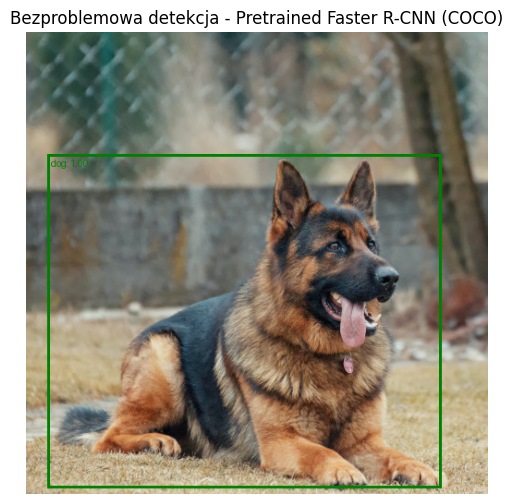

In [5]:
# Ładowanie modelu z wagami pre-trained na COCO i wysłanie na GPU
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_base = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device)
model_base.eval() # Tryb ewaluacji

# Wczytanie obrazu i wysłanie na GPU
img = read_image("data/sample_dog.jpg")
img_float = F.convert_image_dtype(img, dtype=torch.float).to(device)

# Predykcja
with torch.no_grad():
    predictions = model_base([img_float])[0]

# Rysowanie bezproblemowych wyników (filtrowanie score > 0.8)
scores = predictions["scores"].cpu()
boxes = predictions["boxes"].cpu()
labels_idx = predictions["labels"].cpu()

keep = scores > 0.8
boxes_keep = boxes[keep]
labels_keep = [f"{weights.meta['categories'][l]}: {s:.2f}" for l, s in zip(labels_idx[keep], scores[keep])]

result_img = draw_bounding_boxes(img, boxes_keep, labels_keep, colors="green", width=3)

plt.figure(figsize=(10, 6))
plt.imshow(result_img.permute(1, 2, 0))
plt.title("Bezproblemowa detekcja - Pretrained Faster R-CNN (COCO)")
plt.axis("off")
plt.show()

## 4. Krytyczna analiza i weryfikacja eksperymentalna

### Eksperyment 1: Wpływ progu pewności (Confidence Threshold) i NMS
Architektura Faster R-CNN generuje bardzo wiele propozycji z RPN. Parametry `box_score_thresh` oraz `box_nms_thresh` (Non-Maximum Suppression) odpowiadają za filtrowanie tych propozycji. Zobaczmy, co się stanie przy skrajnie błędnych ustawieniach.

Liczba obiektów przy standardowych parametrach (poprzednia sekcja): 3
Liczba obiektów przy 'zepsutych' parametrach (score>0.05, NMS=0.9): 21


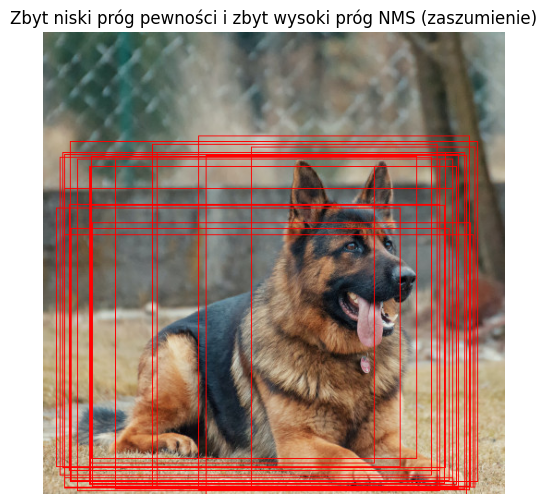

In [6]:
EXPERIMENT_SCORE_THRESH = 0.05
EXPERIMENT_NMS_THRESHOLD = 0.9 # Blisko 1.0 -> pozwala na zostawienie duplikatów ramek

model_exp1 = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=weights,
    box_score_thresh=EXPERIMENT_SCORE_THRESH,
    box_nms_thresh=EXPERIMENT_NMS_THRESHOLD 
).to(device)
model_exp1.eval()

with torch.no_grad():
    preds_exp1 = model_exp1([img_float])[0]

boxes_exp1 = preds_exp1["boxes"].cpu()

print(f"Liczba obiektów przy standardowych parametrach (poprzednia sekcja): {len(boxes)}")
print(f"Liczba obiektów przy 'zepsutych' parametrach (score>0.05, NMS=0.9): {len(boxes_exp1)}")

# Wizualizacja 'chaosu'
result_img_exp1 = draw_bounding_boxes(img, boxes_exp1, colors="red", width=1)
plt.figure(figsize=(10, 6))
plt.imshow(result_img_exp1.permute(1, 2, 0))
plt.title("Zbyt niski próg pewności i zbyt wysoki próg NMS (zaszumienie)")
plt.axis("off")
plt.show()

## Eksperyment 3: Analiza False Positives (Shift domenowy)
Model Faster R-CNN (z wagami COCO) był trenowany na prawdziwych fotografiach. Kiedy zaprezentujemy mu dane z innej domeny wizualnej – np. obraz artystyczny taki jak "Krzyk" Edvarda Muncha – sieć zaczyna "halucynować". Przy średnim progu ufności (0.3) potrafi wykrywać fałszywe obiekty w abstrakcyjnych plamach farby.

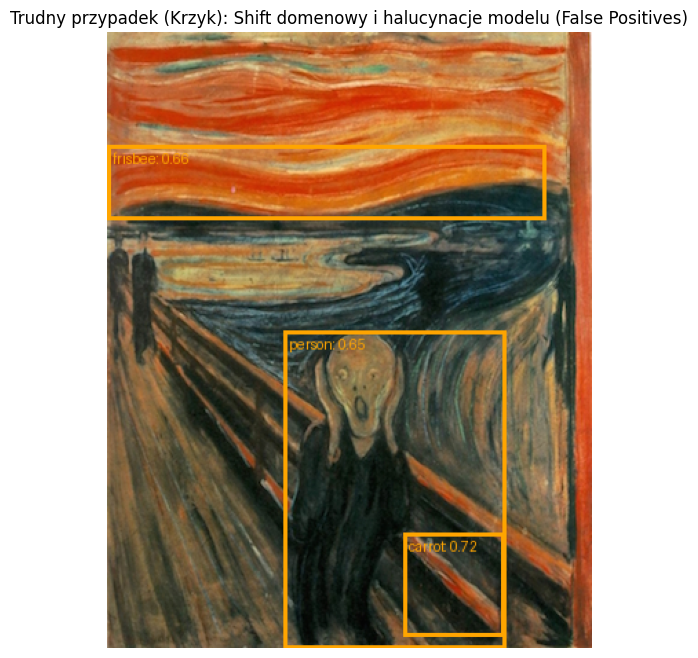

In [12]:
import urllib.request
import os

# Pobieramy obraz sztuki (Krzyk - E. Munch)
scream_path = "data/scream.jpg"
scream_url = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/scream.jpg"

if not os.path.exists(scream_path):
    req = urllib.request.Request(scream_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(scream_path, 'wb') as out_file:
        out_file.write(response.read())

img_scream = read_image(scream_path)
img_scream_float = F.convert_image_dtype(img_scream, dtype=torch.float).to(device)

model_base = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()

with torch.no_grad():
    preds_scream = model_base([img_scream_float])[0]

# Filtrujemy by uwypuklić błędne detekcje (halucynacje) w nietypowej domenie
keep_scream = preds_scream["scores"] > 0.3
boxes_scream = preds_scream["boxes"][keep_scream].cpu()
scores_scream = preds_scream["scores"][keep_scream].cpu()
labels_scream = [f"{weights.meta['categories'][l]}: {s:.2f}" for l, s in zip(preds_scream["labels"][keep_scream].cpu(), scores_scream)]

result_img_scream = draw_bounding_boxes(img_scream, boxes_scream, labels_scream, colors="orange", width=3)

plt.figure(figsize=(10, 8))
plt.imshow(result_img_scream.permute(1, 2, 0))
plt.title("Trudny przypadek (Krzyk): Shift domenowy i halucynacje modelu (False Positives)")
plt.axis("off")
plt.show()

### Eksperyment 3: Porównanie z architekturą YOLO (Jednoetapową)
Faster R-CNN to sieć dwuetapowa. Porównajmy czas inferencji z YOLOv8.

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Admin\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Czas predykcji Faster R-CNN: 759.20 ms
Czas predykcji YOLOv8 Nano:  35.00 ms
YOLO jest około 21.7x szybsze.


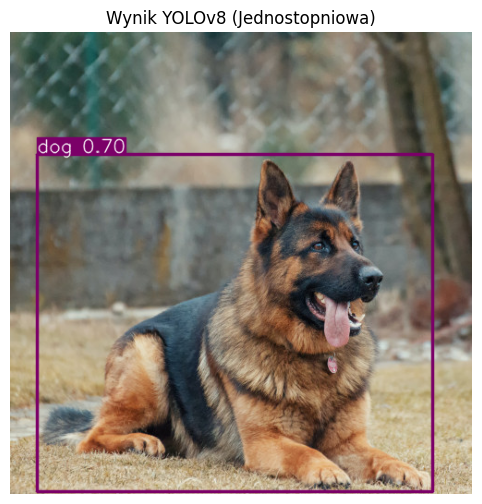

In [9]:
try:
    from ultralytics import YOLO
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "ultralytics", "pycocotools", "-q"])
    from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt') 

# Rozgrzewka GPU (dla dokładnych pomiarów)
with torch.no_grad():
    _ = model_base([img_float])
_ = model_yolo("data/sample_dog.jpg", verbose=False)

# Test czasu: Faster R-CNN
start_rcnn = time.time()
with torch.no_grad():
    _ = model_base([img_float])
end_rcnn = time.time()

# Test czasu: YOLOv8
start_yolo = time.time()
results_yolo = model_yolo("data/sample_dog.jpg", verbose=False)
end_yolo = time.time()

time_rcnn_ms = (end_rcnn - start_rcnn) * 1000
time_yolo_ms = (end_yolo - start_yolo) * 1000

print(f"Czas predykcji Faster R-CNN: {time_rcnn_ms:.2f} ms")
print(f"Czas predykcji YOLOv8 Nano:  {time_yolo_ms:.2f} ms")
if time_yolo_ms > 0:
    print(f"YOLO jest około {time_rcnn_ms/time_yolo_ms:.1f}x szybsze.")

res_plotted = results_yolo[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(res_plotted[:, :, ::-1])
plt.title("Wynik YOLOv8 (Jednostopniowa)")
plt.axis("off")
plt.show()

---
## 5. Rozszerzenie GPU: Fine-tuning na własnym zbiorze danych (Penn-Fudan)

Przeprowadzamy transfer learning modelu dla zaledwie 2 klas (Tło + Pieszy) na zbiorze PennFudanPed.
Aby uniknąć długiego trenowania w notatniku demonstracyjnym, kod automatycznie zapisze wagi po wytrenowaniu, a przy kolejnym uruchomieniu po prostu je wczyta.

Brak zapisanych wag. Rozpoczynam trenowanie (GPU)...


d:\Nauka\PW\magisterskie\III_semestr\ADOM26L-Faster-R-CNN\engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 0:06:04  lr: 0.000090  loss: 7.8292 (7.8292)  loss_classifier: 0.6192 (0.6192)  loss_box_reg: 0.1799 (0.1799)  loss_mask: 7.0154 (7.0154)  loss_objectness: 0.0129 (0.0129)  loss_rpn_box_reg: 0.0019 (0.0019)  time: 6.0783  data: 0.0143
Epoch: [0]  [10/60]  eta: 0:04:26  lr: 0.000936  loss: 1.7569 (3.4305)  loss_classifier: 0.4240 (0.4128)  loss_box_reg: 0.2702 (0.2748)  loss_mask: 1.0615 (2.7157)  loss_objectness: 0.0204 (0.0214)  loss_rpn_box_reg: 0.0033 (0.0059)  time: 5.3379  data: 0.0151
Epoch: [0]  [20/60]  eta: 0:03:34  lr: 0.001783  loss: 0.8715 (2.1457)  loss_classifier: 0.2086 (0.2979)  loss_box_reg: 0.2571 (0.2647)  loss_mask: 0.4031 (1.5567)  loss_objectness: 0.0151 (0.0201)  loss_rpn_box_reg: 0.0049 (0.0063)  time: 5.3378  data: 0.0158
Epoch: [0]  [30/60]  eta: 0:02:40  lr: 0.002629  loss: 0.6129 (1.6370)  loss_classifier: 0.1177 (0.2323)  loss_box_reg: 0.2132 (0.2495)  loss_mask: 0.2298 (1.1325)  loss_objectness: 0.0082 (0.0161)  loss_rpn_box_reg: 

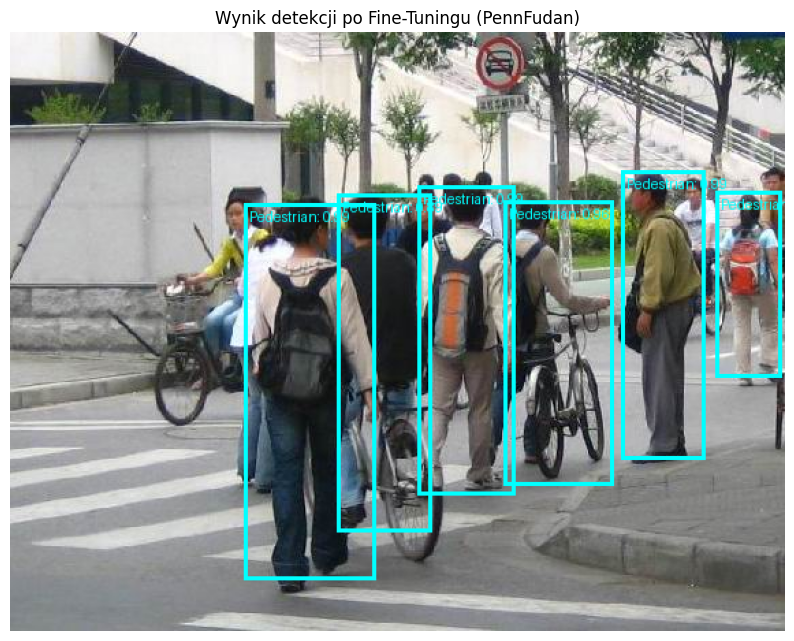

In [11]:
from torchvision.transforms import v2 as T
from torchvision import tv_tensors
from torchvision.ops.boxes import masks_to_boxes
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import utils
from engine import train_one_epoch, evaluate

# 1. Pobranie zbioru danych PennFudan
dataset_path = "data/PennFudanPed"
if not os.path.exists(dataset_path):
    print("Pobieram zbiór danych PennFudanPed...")
    urllib.request.urlretrieve("https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip", dataset_path + ".zip")
    with zipfile.ZipFile(dataset_path + ".zip", 'r') as zip_ref:
        zip_ref.extractall('data')

# 2. Definicja klasy Dataset
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        
        obj_ids = torch.unique(mask)[1:]
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        boxes = masks_to_boxes(masks)
        labels = torch.ones((len(obj_ids),), dtype=torch.int64)
        
        img = tv_tensors.Image(img)
        
        # POPRAWKA: Używamy img.shape[-2:] zamiast F.get_size(img)
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape[-2:]),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": idx,
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(obj_ids),), dtype=torch.int64)
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)
    
# 3. Modyfikacja architektury (zmiana klasyfikatora na 2 klasy)
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

# Inicjalizacja modelu
num_classes = 2
model_ft = get_model_instance_segmentation(num_classes).to(device)
weights_file = "faster_rcnn_pennfudan.pth"

# 4. Trenowanie LUB Ładowanie Wag
if os.path.exists(weights_file):
    print("Znaleziono zapisane wagi! Ładuję wytrenowany model...")
    model_ft.load_state_dict(torch.load(weights_file, map_location=device, weights_only=True))
else:
    print("Brak zapisanych wag. Rozpoczynam trenowanie (GPU)...")
    dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
    dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train=False))

    indices = torch.randperm(len(dataset)).tolist()
    dataset = torch.utils.data.Subset(dataset, indices[:-50])
    dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

    data_loader = torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn)
    data_loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=utils.collate_fn)

    params = [p for p in model_ft.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    for epoch in range(2):
        train_one_epoch(model_ft, optimizer, data_loader, device, epoch, print_freq=10)
        lr_scheduler.step()
        evaluate(model_ft, data_loader_test, device=device)
        
    torch.save(model_ft.state_dict(), weights_file)
    print(f"Trenowanie zakończone. Zapisano wagi do {weights_file}")

# 5. Wizualizacja działania naszego własnego modelu
model_ft.eval()
img_test_penn = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

with torch.no_grad():
    x = eval_transform(img_test_penn, None)[0].to(device)
    pred_ft = model_ft([x])[0]

# Rysujemy wyniki z uwzględnieniem obciętych wartości
keep_ft = pred_ft["scores"] > 0.6
boxes_ft = pred_ft["boxes"][keep_ft].cpu()
labels_ft = [f"Pedestrian: {s:.2f}" for s in pred_ft["scores"][keep_ft].cpu()]

res_img_ft = draw_bounding_boxes(img_test_penn, boxes_ft, labels_ft, colors="cyan", width=3)
plt.figure(figsize=(10, 8))
plt.imshow(res_img_ft.permute(1, 2, 0))
plt.title("Wynik detekcji po Fine-Tuningu (PennFudan)")
plt.axis("off")
plt.show()

## 6. Wnioski końcowe
1. **Zastosowanie:** Faster R-CNN idealnie sprawdza się w zadaniach wymagających wysokiej precyzji, szczególnie w przypadku obiektów małych lub znajdujących się w nietypowym zagęszczeniu. Architektura ta stanowi też doskonałą bazę do rozszerzeń segmentacyjnych (np. Mask R-CNN).
2. **Ograniczenia:** Aplikacje *Real-time* na urządzeniach brzegowych. Testy potwierdziły, że czas inferencji sieci dwuetapowej znacząco ustępuje metodom jednoetapowym (jak YOLO).
3. **Parametry:** RPN jest niezwykle wrażliwy na parametry post-processingu (NMS i Confidence Threshold) – ich niewłaściwy dobór powoduje zalew fałszywych detekcji i duplikatów.